# 1. Import Libraries

In [ ]:
# Libraries used: pandas for csv manipulation, numpy for general-purpose computational efficiency, matplotlib and seaborn for plotting, xgboost for model construction, sklearn for evaluation and preprocessing
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb


from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

%matplotlib inline
sns.set_style('whitegrid')

# 2. Load and Merge Datasets

In [ ]:
# Merged cleaned o-list dataset with rfm dataset for more robust numerical features
df_cleaned = pd.read_csv('../data/olist_cleaned.csv')
df_rfm = pd.read_csv('../data/olist_rfm.csv')
df_merged = pd.merge(df_cleaned, df_rfm, on='customer_unique_id', how='left')
print(df_merged.head())

                        customer_id  ... churn
0  06b8999e2fba1a1fbc88172c00ba8bc7  ...     1
1  18955e83d337fd6b2def6b18a428ac77  ...     1
2  4e7b3e00288586ebd08712fdd0374a03  ...     0
3  b2b6027bc5c5109e529d4dc6358b12c3  ...     0
4  4f2d8ab171c80ec8364f7c12e35b23ad  ...     0

[5 rows x 42 columns]


# 3. Explore Statistical Summary of the Data

In [72]:
print("Statistical Summary")
display(df_merged.describe())

Statistical Summary


,customer_zip_code_prefix,order_item_id,price,freight_value,payment_sequential,payment_installments,payment_value,review_score,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,seller_zip_code_prefix,recency,frequency,monetary,churn
count,117329.000000,117329.000000,117329.000000,117329.000000,117329.000000,117329.000000,117329.000000,117329.000000,117329.000000,117329.000000,117329.000000,117329.000000,117329.000000,117329.000000,117329.000000,117329.000000,117329.000000,117329.000000,117329.000000,117329.000000
mean,35060.118112,1.194121,120.524349,20.027514,1.094452,2.940151,172.062565,4.031467,48.814709,783.118649,2.188112,2110.522582,30.253561,16.611861,23.070929,24450.781955,244.210869,1.088512,376.458888,0.606184
std,29849.496175,0.684225,182.944843,15.828077,0.731174,2.775370,265.388194,1.387927,9.968552,648.032799,1.711386,3784.851117,16.176285,13.451561,11.744942,27582.364358,153.146176,0.399972,1574.501647,0.488597
min,1003.000000,1.000000,0.850000,0.000000,1.000000,0.000000,0.000000,1.000000,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000,1001.000000,1.000000,1.000000,9.590000,0.000000
25%,11250.000000,1.000000,39.900000,13.080000,1.000000,1.000000,60.750000,4.000000,43.000000,348.000000,1.000000,300.000000,18.000000,8.000000,15.000000,6429.000000,120.000000,1.000000,70.540000,0.000000
50%,24240.000000,1.000000,74.900000,16.280000,1.000000,2.000000,108.100000,5.000000,52.000000,600.000000,1.000000,700.000000,25.000000,13.000000,20.000000,13660.000000,224.000000,1.000000,134.900000,1.000000
75%,58770.000000,1.000000,134.900000,21.180000,1.000000,4.000000,189.060000,5.000000,57.000000,976.000000,3.000000,1800.000000,38.000000,20.000000,30.000000,28035.000000,353.000000,1.000000,282.400000,1.000000
max,99990.000000,21.000000,6735.000000,409.680000,29.000000,24.000000,13664.080000,5.000000,76.000000,3992.000000,20.000000,40425.000000,105.000000,105.000000,118.000000,99730.000000,729.000000,16.000000,109312.640000,1.000000


# 4. Prepare Features and Target, Split Data

In [ ]:
# Feature matrix for training model, removed recency due to data leakage (recency is directly tied to calculation of churn)
features = [
    'price',
    'freight_value', 
    'payment_installments',
    'review_score',
    'frequency',
    'monetary'
]
X = df_merged[features]
# Churn is used as target vector for model
y = df_merged['churn']

# Standardize numerical variables for model training
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 70/30 training-testing split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 5. Build and Train XGBoost Model

In [ ]:
params = {
    'objective': 'binary:logistic', #learning objective for the model, in this case churn is binary, so we will use a binary classifier
    'max_depth':4, # higher depth leads to potential overfitting
    'learning_rate': 0.1, 
    'n_estimators': 100, # number of trees for model
    'alpha': 10 
    }

# instantiate model and fit to training set
model = XGBClassifier(**params)
model.fit(X_train, y_train)
# predict on test data
y_pred = model.predict(X_test)
print(X)

         price  freight_value  ...  frequency  monetary
0       124.99          21.88  ...          1    146.87
1       289.00          46.48  ...          1    335.48
2       139.94          17.79  ...          1    157.73
3       149.94          23.36  ...          1    173.30
4       230.00          22.25  ...          1    252.25
...        ...            ...  ...        ...       ...
117324   74.90          13.88  ...          1     88.78
117325  114.90          14.16  ...          1    129.06
117326   37.00          19.04  ...          1     56.04
117327  689.00          22.07  ...          1    711.07
117328   13.99           7.78  ...          1     21.77

[117329 rows x 6 columns]


# 6. Evaluate Model Accuracy and Performance

Model Accuracy: 0.7699366459274412
Classification Report
              precision    recall  f1-score   support

           0       0.80      0.56      0.66     13826
           1       0.76      0.91      0.83     21373

    accuracy                           0.77     35199
   macro avg       0.78      0.73      0.74     35199
weighted avg       0.77      0.77      0.76     35199



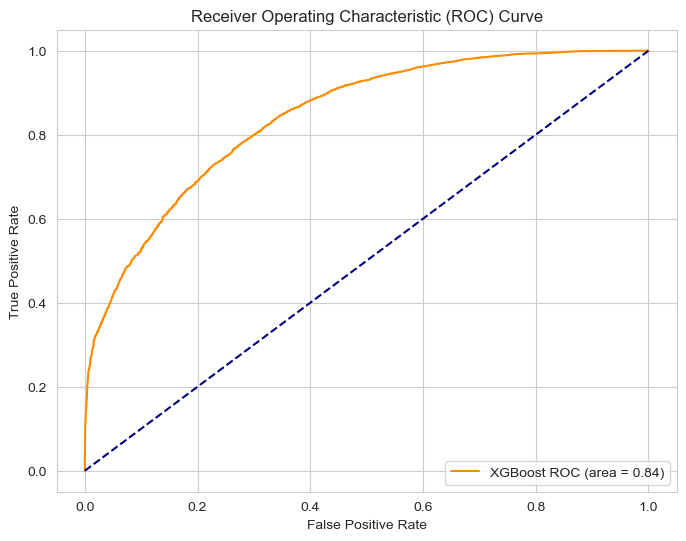

In [ ]:
from sklearn.metrics import roc_curve, auc
accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy:", accuracy)

print("Classification Report")
print(classification_report(y_test, y_pred))

y_probs = model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

# plot ROC score for model
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', label=f'XGBoost ROC (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()


# 7. Plot Feature Importance

<Figure size 800x600 with 0 Axes>

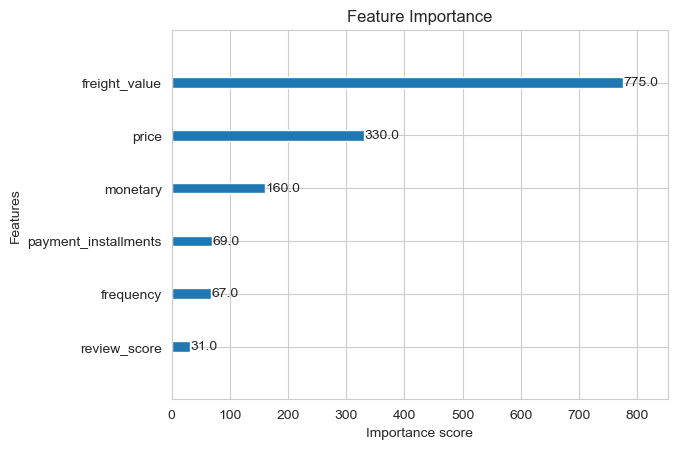

In [76]:
plt.figure(figsize=(8,6))
xgb.plot_importance(model)
plt.title("Feature Importance")
plt.show()

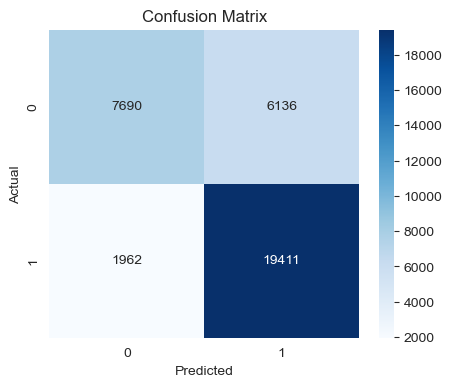

In [62]:
plt.figure(figsize=(5,4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

<Figure size 2000x1000 with 0 Axes>

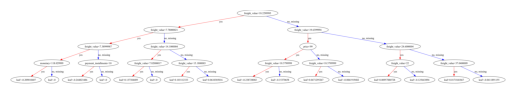

In [69]:
plt.figure(figsize=(20, 10))
xgb.plot_tree(model, tree_idx=0)
plt.savefig('tree.png', dpi=300, bbox_inches='tight')
plt.show()